<center><h1><b>LABORATORY 2</b></h1></center>

---

# Exercise 1 - Discrete random variable

#### 1. Write the R functions for the PMF and cumulative distribution (CDF), using the R naming convention.

In [2]:
# here n is the number of trials, p is the probability of success in each trial, and k is the number of successes we are interested in
pmf_ztb <- function(k, n, p) { dbinom(k,n,p)/( 1-(1-p)^n ) }
cdf_ztb <- function(k, n, p) { pbinom(k,n,p)/( 1-(1-p)^n ) - dbinom(0,n,p)/( 1-(1-p)^n ) }
    

alternatives: with sapply or with cumsum

#### 2. Produce two plots showing the PMF and CDF, separately.

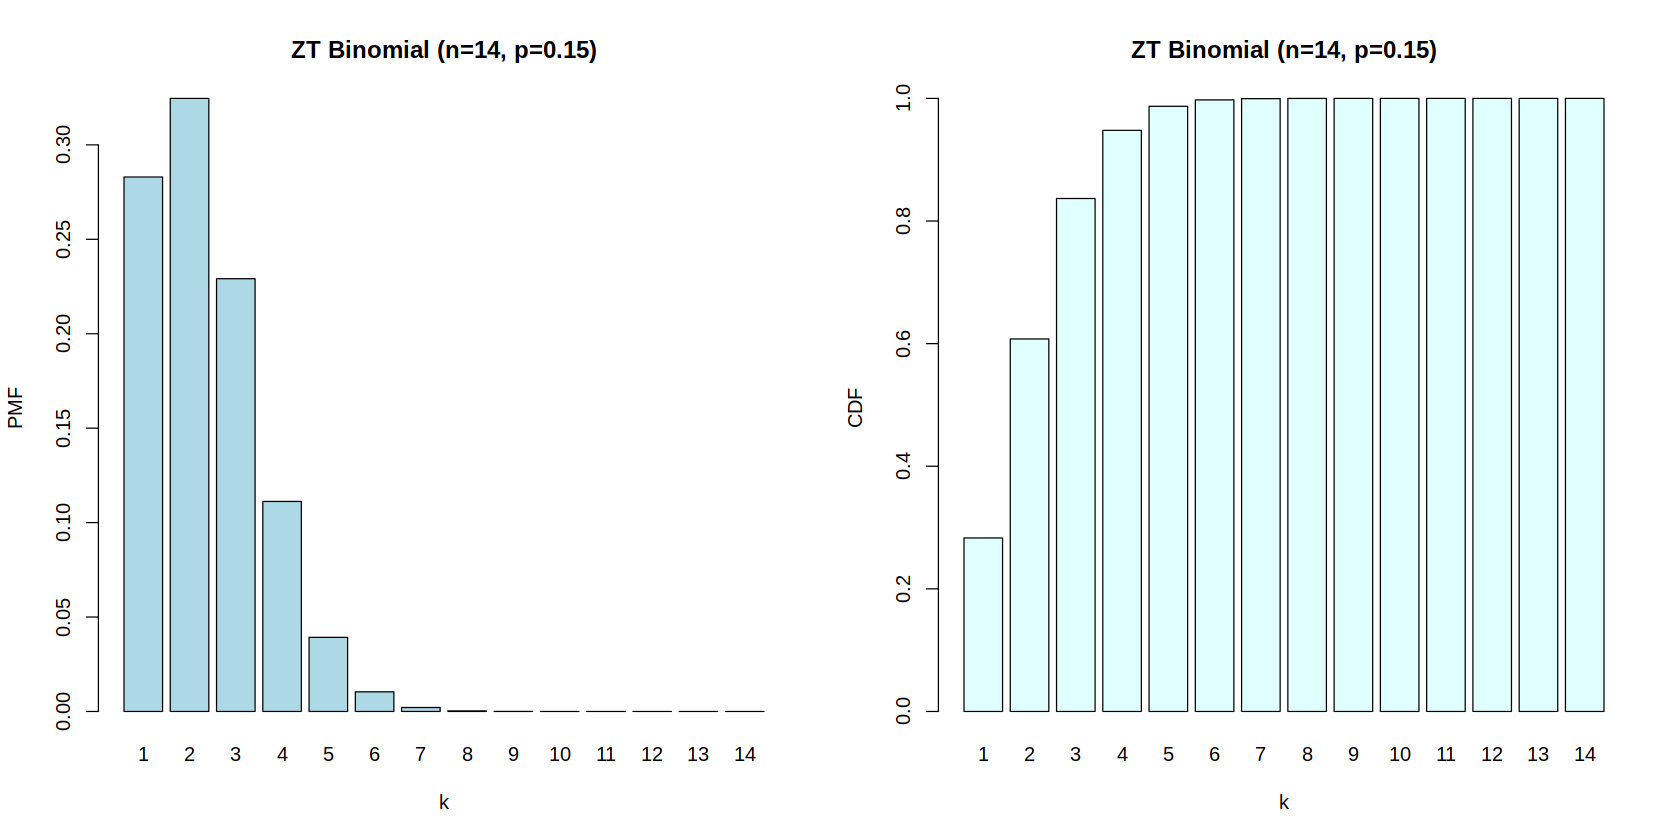

In [10]:
# VALUES:
n <- 14
p <- 0.15
k_values <- 1:n
pmf_val <- pmf_ztb(k_values, n, p)
cdf_val <- cdf_ztb(k_values, n, p)

# PLOT:
options(repr.plot.width = 14, repr.plot.height = 7)
par(mfrow = c(1, 2))  # 1 row and 2 columns
barplot( pmf_val, main='ZT Binomial (n=14, p=0.15)', ylab='PMF', xlab='k', col="lightblue", names.arg=k_values )
barplot( cdf_val, main='ZT Binomial (n=14, p=0.15)', ylab='CDF', xlab='k', col="lightcyan", names.arg=k_values )

#### 3. Compute the mean value and variance of the ZTB distribution using R. Compare the obtained values with the analytical statistical moments for the zero-truncated and the standard binomial distributions.

In [21]:
# NUMERICAL MEAN AND VARIANCE of ztb: (using definitions of mean and variance)
ztb_mean_num <- sum(k_values*pmf_val)
ztb_var_num  <- sum(k_values^2 * pmf_val) - ztb_mean_num^2
print( paste( 'NUMERICAL MEAN of ztb: ', format(ztb_mean_num, digits = 5) , ' VARIANCE: ' , format(ztb_var_num, digits = 5) ))

# ANALYTICAL MEAN AND VARIANCE of ztb:
ztb_mean_ana <- n*p / ( 1-(1-p)^n )
ztb_var_ana  <- (n*p*((1-p)-(1-p+n*p)*(1-p)^n))/(1-(1-p)^n)^2   # da fare un check
print( paste( 'ANALYTICAL MEAN of ztb:', format(ztb_mean_ana, digits = 5) , ' VARIANCE: ' , format(ztb_var_ana, digits = 5) ))

# ANALYTICAL MEAN AND VARIANCE of standard binomial:
bin_mean <- n*p
bin_var <- n*p*(1-p)
print( paste( 'ANALYTICAL MEAN of bin:', format(bin_mean, digits = 5) , ' VARIANCE: ' , format(bin_var, digits = 5) ))


[1] "NUMERICAL MEAN of ztb:  2.3405  VARIANCE:  1.4265"
[1] "ANALYTICAL MEAN of ztb: 2.3405  VARIANCE:  1.4265"
[1] "ANALYTICAL MEAN of bin: 2.1  VARIANCE:  1.785"


#### 4. Generate a sample of random numbers from this distribution, show them in an histogram, and evaluate the sample mean.

Mean value: 2.337962 


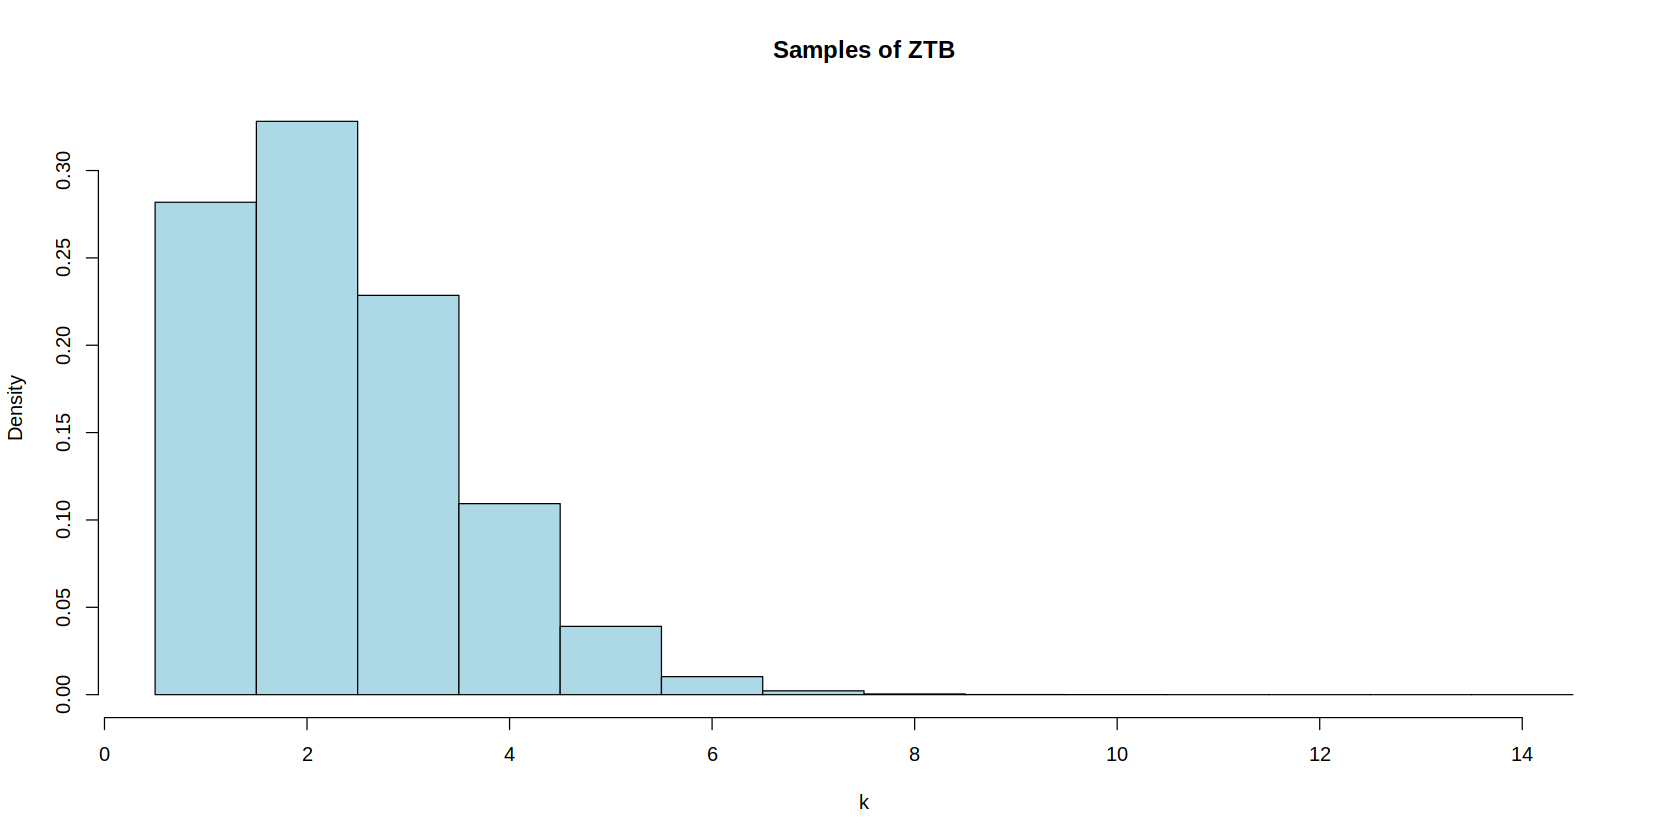

In [46]:
N <- 100000                        # number of samples
samples <- rbinom(N, n, p)
samples <- samples[samples != 0]   # removing zeros
mean_samples <- mean(samples)      # Compute sample mean

# PLOT:
hist(   samples,
        breaks = seq(1/2, 29/2,1), 
        xlab = "k", main = "Samples of ZTB", col = "lightblue",
        probability=TRUE
)

cat("Mean value:", mean_samples, "\n")

---

# Exercise 2 - Continuous random variable